# LiH ground-state energy with Sample-Based Quantum Diagonalization (SQD) — plus a VQE comparison

**Pipeline:** Molecule → trial circuit → measured configurations → selected subspace → classical diagonalization → energy.

| Step | What we do |
|---|---|
| 0 | Install & imports |
| 1 | Define the chemistry problem (LiH / STO-3G, frozen core, 2e in 5 orbitals), HF + exact references |
| 2 | Trial circuit (UCCSD seeded with **classical CCSD amplitudes**, no optimisation) and finite-shot sampling |
| 3 | SQD: bitstrings → alpha/beta configurations → projected Hamiltonian → lowest eigenvalue |
| 4 | Accuracy vs bond length (SQD vs random-configuration baseline vs HF vs exact) |
| 5 | Budget study: error vs shots and vs retained subspace size, repeated over seeds |
| 6 | VQE (optional comparison) with transparent cost accounting |
| 6.5 | Four-method energy-versus-bond-length comparison (HF, exact, SQD, VQE) |
| 7 | Controlled design test: *which circuit supplies the configurations?* (CCSD-seeded vs VQE-trained vs random-angle) |
| 8 | Operation-count/resource comparison |
| 8.75 | Why SQD works: exact determinant-weight capture, oracle/random selectors, and larger-space scaling |
| 9 | Cost ledger and conclusions |

All energies are **total energies in hartree (Ha)**; errors are in **millihartree (mHa)** relative to the exact energy of the *same* finite Hamiltonian and particle sector (not an experimental energy).


## Step 0 — Setup (Colab)

In [1]:
!pip install -q qiskit qiskit-aer qiskit-addon-sqd qiskit-nature pyscf scipy matplotlib pandas


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import time, warnings, itertools
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
from scipy.optimize import minimize
from importlib.metadata import version
warnings.filterwarnings("ignore")

from pyscf import gto, scf, mcscf, ao2mo, fci, cc
from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_addon_sqd.fermion import solve_fermion

for p in ["qiskit","qiskit-aer","qiskit-addon-sqd","qiskit-nature","pyscf","numpy","scipy"]:
    print(f"{p:18s}{version(p)}")

MHA = 1e3          # hartree -> millihartree
LEDGER = []        # every quantum/classical cost is logged here (Step 8)
def log(stage, **kw): LEDGER.append(dict(stage=stage, **kw))

qiskit            2.5.2
qiskit-aer        0.17.2
qiskit-addon-sqd  0.13.1
qiskit-nature     0.8.0
pyscf             2.14.0
numpy             2.5.3
scipy             1.18.1


## Step 1 — The chemistry problem

### Physics behind it
* **Born–Oppenheimer:** nuclei are fixed point charges; we solve only the electronic Schrödinger equation $H_{el}\Psi=E\Psi$ and add the classical nuclear repulsion $E_{nn}$ at the end.
* **Second quantization:** in a finite orbital basis,
  $$H=E_{\rm core}+\sum_{pq,\sigma}h_{pq}\,a^\dagger_{p\sigma}a_{q\sigma}+\tfrac12\sum_{pqrs,\sigma\tau}(pq|rs)\,a^\dagger_{p\sigma}a^\dagger_{r\tau}a_{s\tau}a_{q\sigma}.$$
  Here $h_{pq}$ are one-electron integrals (kinetic + electron–nucleus) and $(pq|rs)$ are two-electron repulsion integrals.
* **Hartree–Fock (HF):** the best *single* Slater determinant. It misses **electron correlation**: the energy gap HF→exact is the "correlation energy", which grows when the bond is stretched.
* **STO-3G LiH:** 6 spatial orbitals (Li 1s,2s,2p×3; H 1s), 4 electrons. **Frozen core:** the lowest (essentially Li 1s) orbital stays doubly occupied; its energy and its mean-field effect on the rest are folded into the constant $E_{\rm core}$ (= nuclear repulsion + frozen-core energy) and into $h_{pq}$. This leaves **2 electrons in 5 spatial orbitals** = 10 spin orbitals = **10 qubits**.
* **Configurations (determinants):** which spin orbitals are occupied. With one α and one β electron in 5 orbitals there are $5\times5=25$ determinants. SQD works in a subspace of these.
* **Mapping / bit ordering (important):** Jordan–Wigner, occupation encoding, qubit $k<5$ = α spatial orbital $k$, qubit $5+k$ = β orbital $k$. A Qiskit bitstring is printed with qubit 0 on the right, so it reads **`[β4…β0][α4…α0]`**: the left 5 characters are β, the right 5 are α.

Exact reference = diagonalising $H$ in the fixed $(N_\alpha,N_\beta)=(1,1)$ sector with PySCF's FCI solver, cross-checked against the qubit Hamiltonian.

In [3]:
NORB, NA, NB, NFROZEN = 5, 1, 1, 1      # Number of orbitals, alpha electrons, beta electrons, frozen orbitals
GEOMS = [1.0, 1.4, 1.6, 2.0, 2.4, 3.0]          # Å  (near-equilibrium ... stretched)
mapper = JordanWignerMapper()       # Mapping from fermionic annhilation/creation operators to the pauli operators (qbit operators)

def build_problem(R):
    mol = gto.M(atom=f"Li 0 0 0; H 0 0 {R}", basis="sto-3g", unit="Angstrom",
                charge=0, spin=0, verbose=0)  # Constructing the molecular geometry in cartesian coordinates (Angestroms)
    mf = scf.RHF(mol).run()         # Running a self-consistent field calculation to obtain the Hartree-Fock energy and wavefunctions (molecular orbitals)
    mc = mcscf.CASCI(mf, NORB, (NA, NB))            # ncore = 1 doubly occupied frozen orbital
    h1, ecore = mc.get_h1eff()                      # ecore = E_nuc + frozen-core energy (counted once)
    h2 = ao2mo.restore(1, mc.get_h2eff(), NORB)
    e_exact, _ = fci.direct_spin1.FCI().kernel(h1, h2, NORB, (NA, NB))
    t0 = time.perf_counter()
    ccs = cc.CCSD(mf, frozen=NFROZEN).run()         # classical preprocessing (used to seed the circuit)
    log("classical_CCSD", R=R, seconds=time.perf_counter() - t0)
    Hq = mapper.map(ElectronicEnergy.from_raw_integrals(h1, h2).second_q_op())
    return dict(R=R, mol=mol, mf=mf, h1=h1, h2=h2, ecore=ecore, ccsd=ccs,
                e_hf=mf.e_tot, e_exact=e_exact + ecore,
                e_ccsd=ccs.e_tot, Hq=Hq, M=Hq.to_matrix(sparse=True))

PROB = {R: build_problem(R) for R in GEOMS}
ref = pd.DataFrame([{"R (Å)": R, "E_HF (Ha)": p["e_hf"], "E_exact (Ha)": p["e_exact"],
                     "E_CCSD (Ha)": p["e_ccsd"],
                     "corr. energy (mHa)": (p["e_exact"] - p["e_hf"]) * MHA} for R, p in PROB.items()])
ref.round(6)

,R (Å),E_HF (Ha),E_exact (Ha),E_CCSD (Ha),corr. energy (mHa)
0,1.0,-7.767362,-7.784021,-7.784021,-16.659185
1,1.4,-7.860539,-7.878231,-7.878231,-17.691992
2,1.6,-7.861865,-7.882097,-7.882097,-20.231830
3,2.0,-7.830906,-7.860828,-7.860828,-29.922674
4,2.4,-7.783382,-7.830343,-7.830343,-46.961325
5,3.0,-7.710830,-7.798504,-7.798504,-87.674322


In [4]:
# --- Consistency checks: the pieces must describe the same Hamiltonian ---
p = PROB[1.6]
n_q = p["Hq"].num_qubits
alpha_strs = [1 << k for k in range(NORB)]           # one electron in orbital k
idx = [(b << NORB) | a for a in alpha_strs for b in alpha_strs]   # basis index = beta bits << 5 | alpha bits
e_qubit_sector = np.linalg.eigvalsh(p["M"][idx][:, idx].toarray())[0] + p["ecore"]
print("qubits:", n_q, "| Pauli terms:", len(p["Hq"]))
print(f"exact (PySCF FCI)            : {p['e_exact']:.9f} Ha")
print(f"exact (qubit H, (1,1) sector): {e_qubit_sector:.9f} Ha")
print(f"CASCI total (nuc+core incl.) : {mcscf.CASCI(p['mf'], NORB, (NA,NB)).kernel()[0]:.9f} Ha")
assert abs(e_qubit_sector - p["e_exact"]) < 1e-8

qubits: 10 | Pauli terms: 276
exact (PySCF FCI)            : -7.882096600 Ha
exact (qubit H, (1,1) sector): -7.882096600 Ha
CASCI total (nuc+core incl.) : -7.882096600 Ha


## Step 2 — Trial circuit and finite-shot sampling

### Why a circuit at all?
The full space has $\binom{5}{1}^2=25$ determinants here, but it grows combinatorially with orbitals/electrons. SQD asks the quantum computer only to **propose which determinants matter**: we measure a trial state $|\psi\rangle$ in the computational basis and keep the configurations that appear.

### Our trial state (no exact ground state is used)
* Start from the **Hartree–Fock determinant** (`HartreeFock` initial state: one α and one β electron in orbital 0 — X gates).
* Apply a **UCCSD** ansatz $\prod_k e^{\theta_k(T_k-T_k^\dagger)}$ with the amplitudes $\theta_k$ **set directly from classical CCSD amplitudes** $t_1,t_2$ (computed with PySCF on the same frozen-core model). **No variational optimisation** is performed. This is the "classical chemistry information" fed to the circuit; its cost is logged.
* Because UCCSD excitations conserve particle number, every noiseless sample has the right α/β electron count; invalid bitstrings can only come from noise.
* Sampling is done by `AerSimulator` with finite shots and a fixed seed; the circuit is transpiled to `{cx, rz, sx, x}` so we can report depth and two-qubit gate counts.

In [5]:
ans = UCCSD(NORB, (NA, NB), mapper, initial_state=HartreeFock(NORB, (NA, NB), mapper))
HF_STATE = Statevector(HartreeFock(NORB, (NA, NB), mapper)).data.astype(complex)
GEN = [op.to_matrix(sparse=True) for op in ans.operators]    # generators of each excitation exp(-i θ G)
print("UCCSD parameters:", ans.num_parameters, "| qubits:", ans.num_qubits)

def ccsd_params(p):
    # map CCSD t1/t2 onto the UCCSD excitation list (spin-orbital indices: α 0-4, β 5-9)
    x = []
    for occ, virt in ans.excitation_list:
        if len(occ) == 1:
            x.append(p["ccsd"].t1[occ[0] % NORB, virt[0] % NORB - NFROZEN])
        else:
            (i, j), (a, b) = occ, virt
            x.append(p["ccsd"].t2[i % NORB, j % NORB, a % NORB - NFROZEN, b % NORB - NFROZEN])
    return np.array(x)

def fast_state(x):
    # Exact statevector of the same UCCSD unitary (each excitation's Pauli terms commute -> exact product).
    # Used ONLY to optimise VQE quickly and to sanity-check energies, never to generate SQD samples.
    psi = HF_STATE.copy()
    for k, G in enumerate(GEN):
        psi = expm_multiply(-1j * x[k] * G, psi)
    return psi

def energy_exact_sv(p, x):
    psi = fast_state(x); return float(np.real(psi.conj() @ (p["M"] @ psi))) + p["ecore"]

# sanity: the CCSD-seeded state should lie between HF and exact (variational)
for R in (1.6, 2.4):
    p = PROB[R]; e = energy_exact_sv(p, ccsd_params(p))
    print(f"R={R}: HF {p['e_hf']:.6f}  CCSD-seeded circuit <H> {e:.6f}  exact {p['e_exact']:.6f}")
    assert p["e_exact"] - 1e-9 <= e <= p["e_hf"] + 1e-9

UCCSD parameters: 24 | qubits: 10
R=1.6: HF -7.861865  CCSD-seeded circuit <H> -7.879824  exact -7.882097
R=2.4: HF -7.783382  CCSD-seeded circuit <H> -7.815950  exact -7.830343


In [6]:
BASIS = ["cx", "rz", "sx", "x"]
SIM = AerSimulator()
COMPILED = {}

def compile_circuit(key, x):
    # bind parameters, add measurements, transpile once, cache. Returns (circuit, stats).
    if key in COMPILED: return COMPILED[key]
    qc = ans.assign_parameters(x); qc.measure_all()
    t0 = time.perf_counter()
    tqc = transpile(qc, basis_gates=BASIS, optimization_level=1, seed_transpiler=0)
    dt = time.perf_counter() - t0
    ops = tqc.count_ops()
    stats = dict(qubits=tqc.num_qubits, depth=tqc.depth(), two_qubit=ops.get("cx", 0),
                 total_gates=sum(v for k, v in ops.items() if k not in ("measure", "barrier")))
    log("transpile", key=str(key), seconds=dt, **stats)
    COMPILED[key] = (tqc, stats); return COMPILED[key]

def sample_counts(key, x, shots, seed):
    # finite-shot computational-basis sampling of the circuit
    tqc, _ = compile_circuit(key, x)
    t0 = time.perf_counter()
    counts = SIM.run(tqc, shots=shots, seed_simulator=int(seed)).result().get_counts()
    log("sample_circuit", key=str(key), shots=shots, seed=seed, seconds=time.perf_counter() - t0)
    return counts

key = ("ccsd", 1.6)
c = sample_counts(key, ccsd_params(PROB[1.6]), 2000, seed=0)
print("compiled circuit:", compile_circuit(key, ccsd_params(PROB[1.6]))[1])
print("top outcomes (bitstring = [β4..β0][α4..α0]):", Counter(c).most_common(6))

compiled circuit: {'qubits': 10, 'depth': 730, 'two_qubit': 576, 'total_gates': 1005}
top outcomes (bitstring = [β4..β0][α4..α0]): [('0000100001', 1944), ('1000010000', 25), ('0001010000', 11), ('1000000010', 7), ('0001000001', 6), ('0000100010', 3)]


## Step 3 — Sample-based quantum diagonalization

### The math
Let $S=\{|D_1\rangle,\dots,|D_m\rangle\}$ be the sampled determinants. Build the **projected Hamiltonian**
$$\tilde H_{ij}=\langle D_i|H|D_j\rangle,\qquad \tilde H\,c=E_S\,c,$$
including all **off-diagonal** elements, and take the lowest eigenvalue $E_S$. By the variational (Rayleigh–Ritz) principle $E_S\ge E_{\rm exact}$ (in the matching particle sector), and $E_S$ can only be as good as the subspace is. *Averaging bitstring diagonal energies is not SQD.*

In fact, the off diagonal terms containt information about the electron correlations. Thus one needs to diagonalize this Hamiltonian to find the energies corresponding this $\textbf{correlated}$ system.

### Subspace rule used here (same for quantum and random samples)
1. Split each bitstring into β (left) and α (right) halves.
2. **Invalid samples** (wrong α or β Hamming weight) are **discarded** (no configuration recovery in this clean-sample study); an empty batch gives no energy (`NaN`) and is counted.
3. **Duplicates** are merged; frequencies are kept and used to rank strings.
4. Optional **subspace cap** `max_strings`: keep only the most frequent spin-strings.
5. Optional **`include_hf`**: always add the HF determinant.
6. **Closed-shell symmetrisation** (standard in SQD): the union of α and β strings is used for *both* spins, and the solver works in the **product space** $\mathcal S_\alpha\times\mathcal S_\beta$. Hence **solve dimension = (#strings)²**, which can differ from the number of distinct *sampled* full bitstrings.
7. The product-space diagonalisation is done by `qiskit_addon_sqd.fermion.solve_fermion`; we **independently verify** it against a hand-built projection of the qubit Hamiltonian.

The random baseline draws α and β strings uniformly from the valid ones (so each of the 25 valid full configurations is equally likely) and then runs the **identical** code path.

In [7]:
def parse_counts(counts):
    # bitstring -> (alpha string, beta string) ints; returns frequencies + bookkeeping
    a_cnt, b_cnt, full = Counter(), Counter(), set()
    total = sum(counts.values()); valid = 0
    for s, c in counts.items():
        s = s.replace(" ", "")
        b_bits, a_bits = s[:NORB], s[NORB:]            # left half = β, right half = α
        if a_bits.count("1") != NA or b_bits.count("1") != NB:
            continue                                   # invalid particle number -> discard
        valid += c; a_cnt[int(a_bits, 2)] += c; b_cnt[int(b_bits, 2)] += c; full.add(s)
    return a_cnt, b_cnt, full, total, valid

HF_STR = 1                                             # orbital 0 occupied (bit 0)

def sqd_solve(counts, p, max_strings=None, include_hf=False, symmetrize=True):
    a_cnt, b_cnt, full, total, valid = parse_counts(counts)
    out = dict(shots=total, valid=valid, distinct_full=len(full), energy=np.nan, dim=0, n_strings=0)
    pool = (a_cnt + b_cnt) if symmetrize else None
    if valid == 0 and not include_hf:
        return out                                      # empty batch: no subspace, no energy
    if symmetrize:
        ranked = [s for s, _ in pool.most_common()]
        if max_strings: ranked = ranked[:max_strings]
        if include_hf and HF_STR not in ranked: ranked.append(HF_STR)
        A = B = sorted(ranked)
    else:
        A = [s for s, _ in a_cnt.most_common(max_strings)]; B = [s for s, _ in b_cnt.most_common(max_strings)]
        if include_hf: A = A + [HF_STR] * (HF_STR not in A); B = B + [HF_STR] * (HF_STR not in B)
        A, B = sorted(A), sorted(B)
    t0 = time.perf_counter()
    e, _, _, _ = solve_fermion((A, B), p["h1"], p["h2"], open_shell=True)   # lowest eigenvalue of projected H
    dt = time.perf_counter() - t0
    log("sqd_solve", dim=len(A) * len(B), seconds=dt)
    out.update(energy=e + p["ecore"], dim=len(A) * len(B), n_strings=len(set(A) | set(B)),
               solve_s=dt, A=A, B=B)
    return out

def uniform_counts(shots, seed):
    # random baseline: uniform over valid configurations (1 alpha x 1 beta electron)
    rng = np.random.default_rng(seed)
    a = rng.integers(0, NORB, shots); b = rng.integers(0, NORB, shots)
    return dict(Counter(format(1 << bi, f"0{NORB}b") + format(1 << ai, f"0{NORB}b") for ai, bi in zip(a, b)))

# --- verify the solver against an independent projection of the qubit Hamiltonian ---
p = PROB[2.4]
r = sqd_solve(sample_counts(("ccsd", 2.4), ccsd_params(p), 300, 1), p)
idx = [(b << NORB) | a for a in r["A"] for b in r["B"]]
e_manual = np.linalg.eigvalsh(p["M"][idx][:, idx].toarray())[0] + p["ecore"]
print(f"strings {r['n_strings']}, dim {r['dim']}: solve_fermion {r['energy']:.9f} | manual projection {e_manual:.9f}")
assert abs(r["energy"] - e_manual) < 1e-8 and r["energy"] >= p["e_exact"] - 1e-9

strings 3, dim 9: solve_fermion -7.829937003 | manual projection -7.829937003


## Step 4 — Accuracy vs bond length

We use a fixed budget of **100 shots** per geometry (CCSD-seeded circuit vs uniform baseline), 5 seeds, and report mean ± std of the error, the number of distinct full configurations and the actual solve dimension (the full sector is 25).

In [8]:
SEEDS = [0, 1, 2, 3, 4]
def run_trials(p, tag, x, shots, seeds=SEEDS, **kw):
    rows = []
    for s in seeds:
        counts = uniform_counts(shots, 1000 + s) if tag == "uniform" else sample_counts((tag, p["R"]), x, shots, s)
        r = sqd_solve(counts, p, **kw)
        rows.append(dict(R=p["R"], method=tag, shots=shots, seed=s, err_mHa=(r["energy"] - p["e_exact"]) * MHA,
                         energy=r["energy"], distinct_full=r["distinct_full"], dim=r["dim"], valid=r["valid"]))
    return rows

SHOTS_A = 100
rows = []
for R, p in PROB.items():
    rows += run_trials(p, "ccsd", ccsd_params(p), SHOTS_A)
    rows += run_trials(p, "uniform", None, SHOTS_A)
dfA = pd.DataFrame(rows)
sumA = dfA.groupby(["R", "method"]).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"),
        energy=("energy", "mean"), distinct=("distinct_full", "mean"), dim=("dim", "mean")).reset_index()
tabA = sumA.pivot(index="R", columns="method", values=["energy", "err_mean", "err_std", "distinct", "dim"])
tabA["E_HF"] = [PROB[R]["e_hf"] for R in tabA.index]; tabA["E_exact"] = [PROB[R]["e_exact"] for R in tabA.index]
tabA["HF err (mHa)"] = (tabA["E_HF"] - tabA["E_exact"]) * MHA
tabA.round(5)

energy          err_mean          err_std         distinct          \
method     ccsd  uniform     ccsd uniform     ccsd uniform     ccsd uniform   
R                                                                             
1.0    -7.78132 -7.78402  2.70628     0.0  1.31854     0.0      2.8    24.8   
1.4    -7.87579 -7.87823  2.44163     0.0  1.97889     0.0      3.2    24.8   
1.6    -7.87922 -7.88210  2.87872     0.0  2.53892     0.0      3.0    24.8   
2.0    -7.86015 -7.86083  0.67505     0.0  0.00000     0.0      3.8    24.8   
2.4    -7.82994 -7.83034  0.40595     0.0  0.00000     0.0      6.6    24.8   
3.0    -7.79836 -7.79850  0.14079     0.0  0.00000     0.0      7.2    24.8   

        dim             E_HF  E_exact HF err (mHa)  
method ccsd uniform                                 
R                                                   
1.0     8.0    25.0 -7.76736 -7.78402     16.65918  
1.4     9.4    25.0 -7.86054 -7.87823     17.69199  
1.6     7.0    25.0 -7.86186 -7.88210     20.23183  
2.0     9.0    25.0 -7.83091 -7.86083     29.92267  
2.4     9.0    25.0 -7.78338 -7.83034     46.96133  
3.0     9.0    25.0 -7.71083 -7.79850     87.67432

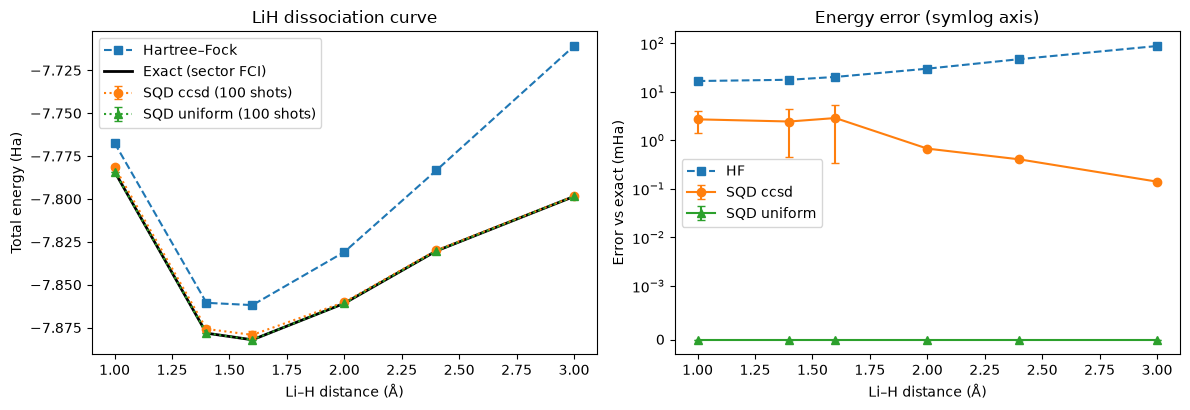

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
Rs = list(PROB)
ax[0].plot(Rs, [PROB[R]["e_hf"] for R in Rs], "s--", label="Hartree–Fock")
ax[0].plot(Rs, [PROB[R]["e_exact"] for R in Rs], "k-", lw=2, label="Exact (sector FCI)")
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = sumA[sumA.method == m]; ax[0].errorbar(d.R, d.energy, d.err_std * 1e-3, fmt=mk + ":", label=f"SQD {m} ({SHOTS_A} shots)", capsize=3)
ax[0].set(xlabel="Li–H distance (Å)", ylabel="Total energy (Ha)", title="LiH dissociation curve"); ax[0].legend()
ax[1].plot(Rs, [(PROB[R]["e_hf"] - PROB[R]["e_exact"]) * MHA for R in Rs], "s--", label="HF")
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = sumA[sumA.method == m]; ax[1].errorbar(d.R, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", label=f"SQD {m}", capsize=3)
ax[1].set(xlabel="Li–H distance (Å)", ylabel="Error vs exact (mHa)", title="Energy error (symlog axis)"); ax[1].set_yscale("symlog", linthresh=1e-3); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 5 — Budget study at a fixed geometry

Geometry: **R = 2.4 Å** (stretched, strongest correlation). Two resource variables, other settings held fixed:

* **(a) shots** ∈ {5, 10, 30, 100, 300, 1000}; no cap on strings. Full sector = 25 determinants (5 strings).
* **(b) retained subspace size** `max_strings` ∈ {1, 2, 3, 4, 5} at 1000 shots (dimension 1, 4, 9, 16, 25).

Five seeds each. Independent seeds are *not nested*, so the error need not decrease monotonically with shots.

In [10]:
R0 = 2.4; p0 = PROB[R0]; x0 = ccsd_params(p0)
rowsB = []
for shots in [5, 10, 30, 100, 300, 1000]:
    rowsB += run_trials(p0, "ccsd", x0, shots); rowsB += run_trials(p0, "uniform", None, shots)
dfB = pd.DataFrame(rowsB)
def agg(df, by):
    return df.groupby(by).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"), err_max=("err_mHa", "max"),
        distinct_mean=("distinct_full", "mean"), distinct_std=("distinct_full", "std"),
        dim_mean=("dim", "mean"), dim_std=("dim", "std")).round(4)
print("(a) error vs shots, R = 2.4 Å (HF error = %.3f mHa)" % ((p0["e_hf"] - p0["e_exact"]) * MHA))
aggB = agg(dfB, ["shots", "method"]); display(aggB)

rowsC = []
for k in [1, 2, 3, 4, 5]:
    rowsC += [dict(r, max_strings=k) for r in run_trials(p0, "ccsd", x0, 1000, max_strings=k)]
    rowsC += [dict(r, max_strings=k) for r in run_trials(p0, "uniform", None, 1000, max_strings=k)]
dfC = pd.DataFrame(rowsC)
print("(b) error vs retained subspace size, 1000 shots"); aggC = agg(dfC, ["max_strings", "method"]); display(aggC)

(a) error vs shots, R = 2.4 Å (HF error = 46.961 mHa)


err_mean   err_std   err_max  distinct_mean  distinct_std  \
shots method                                                               
5     ccsd      31.9335   21.5363   46.9613            1.6        0.8944   
      uniform  164.6359  197.8401  383.1145            4.2        0.8367   
10    ccsd      27.9528   25.1591   46.9613            2.0        1.0000   
      uniform    0.0000    0.0000    0.0000            8.2        1.3038   
30    ccsd       9.3306   19.9562   45.0293            3.4        0.8944   
      uniform    0.0000    0.0000    0.0000           18.0        1.8708   
100   ccsd       0.4059    0.0000    0.4059            6.6        0.8944   
      uniform    0.0000    0.0000    0.0000           24.8        0.4472   
300   ccsd       0.3237    0.1127    0.4059            7.2        0.8367   
      uniform    0.0000    0.0000    0.0000           25.0        0.0000   
1000  ccsd       0.2425    0.1702    0.4059            8.2        0.8367   
      uniform    0.0000    0.0000    0.0000           25.0        0.0000   

               dim_mean  dim_std  
shots method                      
5     ccsd          3.2   3.4928  
      uniform      15.0   6.5955  
10    ccsd          4.8   4.0249  
      uniform      25.0   0.0000  
30    ccsd          8.0   2.2361  
      uniform      25.0   0.0000  
100   ccsd          9.0   0.0000  
      uniform      25.0   0.0000  
300   ccsd         11.8   3.8341  
      uniform      25.0   0.0000  
1000  ccsd         15.0   6.5955  
      uniform      25.0   0.0000

(b) error vs retained subspace size, 1000 shots


err_mean   err_std   err_max  distinct_mean  \
max_strings method                                                 
1           ccsd      46.9613    0.0000   46.9613            8.2   
            uniform  613.8766   32.5535  647.0859           25.0   
2           ccsd      18.3777    0.0000   18.3777            8.2   
            uniform  403.6949  209.4358  531.8839           25.0   
3           ccsd       0.4059    0.0000    0.4059            8.2   
            uniform  268.5778  233.3199  531.8839           25.0   
4           ccsd       0.2825    0.1127    0.4059            8.2   
            uniform   17.6136   23.8443   43.7338           25.0   
5           ccsd       0.2425    0.1702    0.4059            8.2   
            uniform    0.0000    0.0000    0.0000           25.0   

                     distinct_std  dim_mean  dim_std  
max_strings method                                    
1           ccsd           0.8367       1.0   0.0000  
            uniform        0.0000       1.0   0.0000  
2           ccsd           0.8367       4.0   0.0000  
            uniform        0.0000       4.0   0.0000  
3           ccsd           0.8367       9.0   0.0000  
            uniform        0.0000       9.0   0.0000  
4           ccsd           0.8367      13.2   3.8341  
            uniform        0.0000      16.0   0.0000  
5           ccsd           0.8367      15.0   6.5955  
            uniform        0.0000      25.0   0.0000

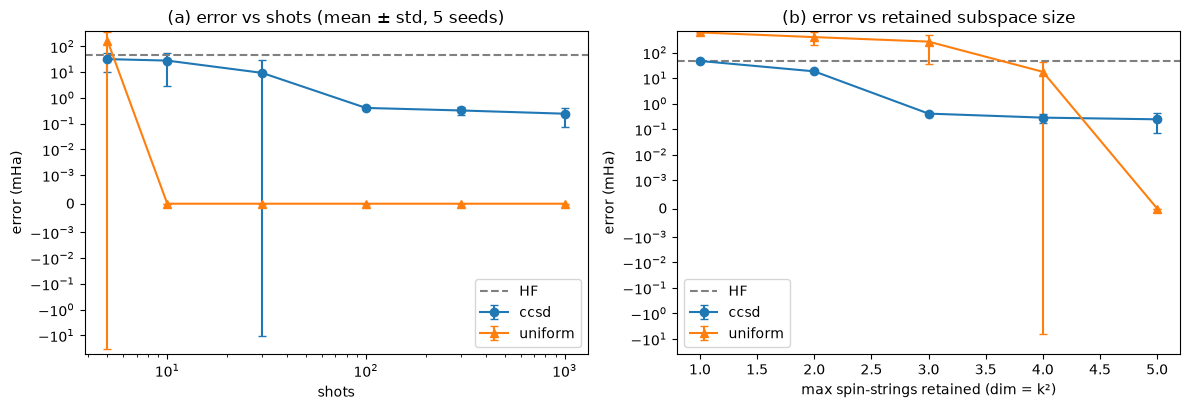

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = aggB.xs(m, level="method"); ax[0].errorbar(d.index, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", capsize=3, label=m)
    d = aggC.xs(m, level="method"); ax[1].errorbar(d.index, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", capsize=3, label=m)
ax[0].axhline((p0["e_hf"] - p0["e_exact"]) * MHA, ls="--", c="gray", label="HF")
ax[1].axhline((p0["e_hf"] - p0["e_exact"]) * MHA, ls="--", c="gray", label="HF")
ax[0].set(xscale="log", xlabel="shots", ylabel="error (mHa)", title="(a) error vs shots (mean ± std, 5 seeds)")
ax[1].set(xlabel="max spin-strings retained (dim = k²)", ylabel="error (mHa)", title="(b) error vs retained subspace size")
ax[0].set_yscale("symlog", linthresh=1e-3); ax[1].set_yscale("symlog", linthresh=1e-3)
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

## Step 6 — VQE (optional comparison)

### Physics
VQE minimises $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)|H|\psi(\boldsymbol\theta)\rangle$ over the same UCCSD circuit (24 parameters), starting from $\boldsymbol\theta=0$ (the HF state). The variational principle guarantees $E(\boldsymbol\theta)\ge E_{\rm exact}$ within the particle sector, and UCCSD preserves the particle number.

### Cost accounting (read carefully)
* To keep Colab runtime small, the optimiser uses an **exact, shot-free statevector** expectation value ("ideal VQE"). This is *not* a finite-shot result. We therefore report the **number of energy evaluations**, the number of **commuting Pauli measurement groups** and a **hypothetical shot cost** if each evaluation were estimated with 1000 shots per group.
* The optimiser is COBYLA, no gradient. Cost of classical optimisation is the wall time and function-evaluation count.

In [12]:
groups = PROB[1.6]["Hq"].group_commuting(qubit_wise=True)
N_GROUPS = len(groups); SHOTS_PER_GROUP = 1000
print("Pauli terms:", len(PROB[1.6]["Hq"]), "| qubit-wise commuting groups:", N_GROUPS)

VQE = {}
for R, p in PROB.items():
    nfev = [0]
    def f(x):
        nfev[0] += 1; return energy_exact_sv(p, x)
    t0 = time.perf_counter()
    res = minimize(f, np.zeros(ans.num_parameters), method="COBYLA", options=dict(maxiter=3000, rhobeg=0.1, tol=1e-9))
    dt = time.perf_counter() - t0
    VQE[R] = dict(x=res.x, energy=res.fun, nfev=nfev[0], seconds=dt)
    log("vqe_optimise", R=R, evals=nfev[0], seconds=dt, hypothetical_shots=nfev[0] * N_GROUPS * SHOTS_PER_GROUP)

tabV = pd.DataFrame([{"R (Å)": R, "E_VQE (Ha)": v["energy"], "VQE err (mHa)": (v["energy"] - PROB[R]["e_exact"]) * MHA,
                      "CCSD-circuit err (mHa)": (energy_exact_sv(PROB[R], ccsd_params(PROB[R])) - PROB[R]["e_exact"]) * MHA,
                      "HF err (mHa)": (PROB[R]["e_hf"] - PROB[R]["e_exact"]) * MHA,
                      "energy evals": v["nfev"], "opt. time (s)": v["seconds"],
                      "hypothetical shots": v["nfev"] * N_GROUPS * SHOTS_PER_GROUP} for R, v in VQE.items()])
tabV.round(5)

Pauli terms: 276 | qubit-wise commuting groups: 58


,R (Å),E_VQE (Ha),VQE err (mHa),CCSD-circuit err (mHa),HF err (mHa),energy evals,opt. time (s),hypothetical shots
0,1.0,-7.78402,0.0,1.33817,16.65918,1105,7.91494,64090000
1,1.4,-7.87823,0.0,1.75609,17.69199,1264,8.36318,73312000
2,1.6,-7.88210,0.0,2.27235,20.23183,1270,8.21181,73660000
3,2.0,-7.86083,0.0,5.03813,29.92267,1273,8.29989,73834000
4,2.4,-7.83034,0.0,14.39274,46.96133,1740,11.48258,100920000
5,3.0,-7.79850,0.0,52.73769,87.67432,2669,17.92848,154802000


## Step 6.5 — Geometry dependence of the four energy methods

This section asks two different questions:

1. **Potential-energy question:** how does the predicted LiH ground-state energy change as the Li–H separation \(R\) changes?
2. **Method-error question:** as the bond is stretched and correlation becomes more important, how far does each approximate method move away from the exact active-space reference?

All four curves use the **same STO-3G frozen-core active-space Hamiltonian** at each geometry.

- **Hartree–Fock (HF):** best single-determinant mean-field state.
- **Exact (sector FCI):** lowest eigenvalue in the full fixed \((N_\alpha,N_\beta)=(1,1)\) active-space sector. This is exact only for the chosen finite model.
- **SQD:** finite-shot sampling from the CCSD-seeded trial circuit followed by classical diagonalization of the sampled determinant subspace. The point is the mean over the Step-4 seeds and the error bar is one standard deviation.
- **VQE:** optimized UCCSD state. In this notebook its energy objective is evaluated with an exact statevector, so the energy curve is an **ideal VQE accuracy benchmark**, not a finite-shot QPU result.

### What should change with geometry?

The exact determinant-sector dimension stays \(5\times5=25\) at every geometry, and the number of qubits stays 10. What changes is the **physics inside that fixed space**. Near equilibrium the ground state is more strongly dominated by the HF-like determinant. At stretched geometries the correlation energy grows and several determinants become more important.

Therefore geometry can change **accuracy at a fixed resource budget** even when the formal problem size is unchanged.

The most informative views below are:

- total energy \(E(R)\), which shows the molecular potential-energy curve;
- error \(E_{\rm method}-E_{\rm exact}\), which reveals differences hidden by the large common total energy;
- correlation-energy recovery,
  \[
  f_{\rm corr}=\frac{E_{\rm HF}-E_{\rm method}}{E_{\rm HF}-E_{\rm exact}},
  \]
  where \(0\) corresponds to HF and \(1\) corresponds to the exact active-space energy.

The random-configuration baseline remains in Steps 4–5 because it answers a different question: whether the quantum sampler selects configurations more usefully than an uninformed baseline.


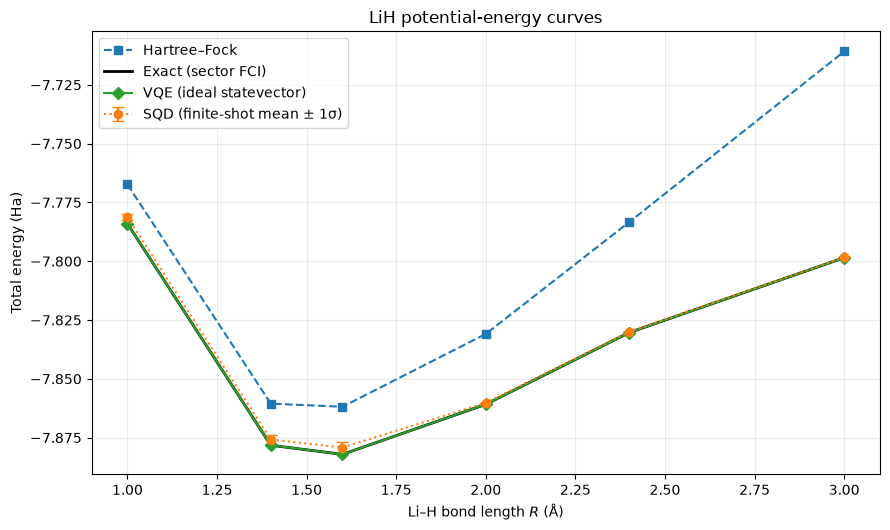

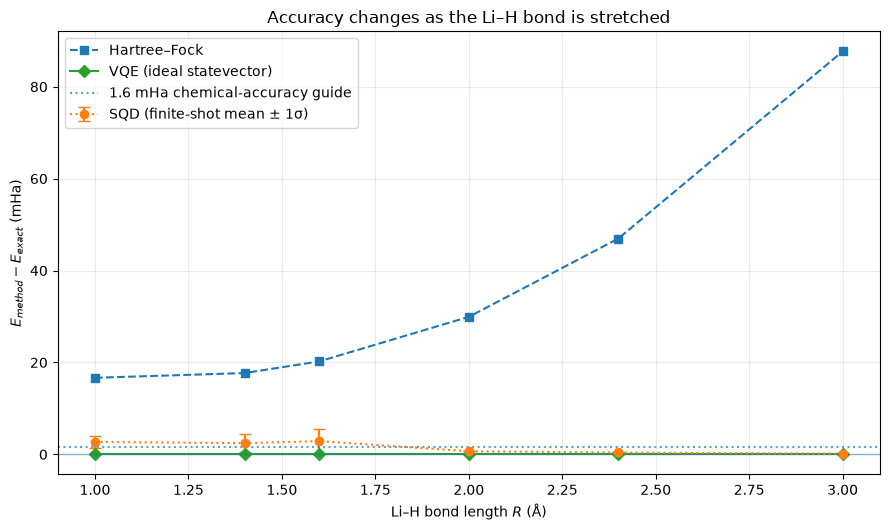

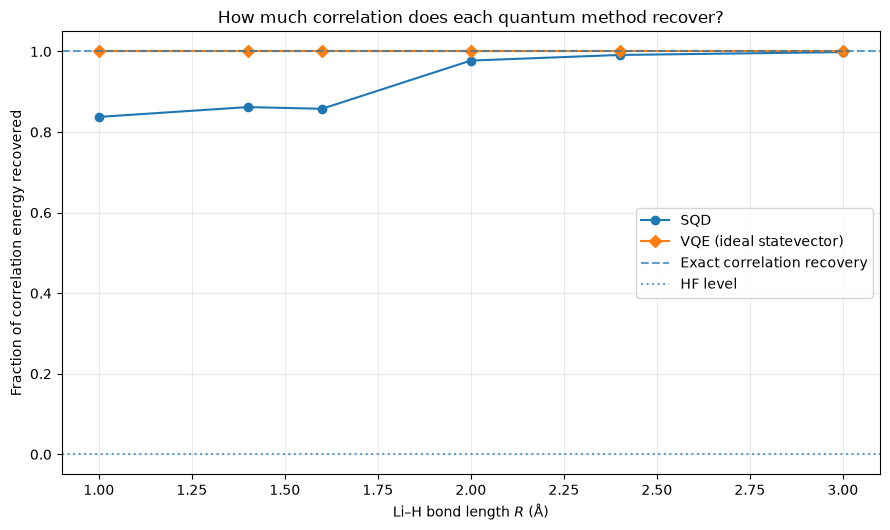

,R (Å),HF (Ha),SQD (Ha),VQE (Ha),Exact (Ha),HF error (mHa),SQD error (mHa),SQD seed std (mHa),VQE error (mHa),SQD corr. recovered,VQE corr. recovered
0,1.0,-7.767362,-7.781315,-7.784021,-7.784021,16.659185,2.706278,1.318544,0.0,0.837550,1.0
1,1.4,-7.860539,-7.875789,-7.878231,-7.878231,17.691992,2.441633,1.978894,0.0,0.861992,1.0
2,1.6,-7.861865,-7.879218,-7.882097,-7.882097,20.231830,2.878718,2.538915,0.0,0.857713,1.0
3,2.0,-7.830906,-7.860153,-7.860828,-7.860828,29.922674,0.675051,0.000000,0.0,0.977440,1.0
4,2.4,-7.783382,-7.829937,-7.830343,-7.830343,46.961325,0.405950,0.000000,0.0,0.991356,1.0
5,3.0,-7.710830,-7.798363,-7.798504,-7.798504,87.674322,0.140792,0.000000,0.0,0.998394,1.0


In [13]:
# ============================================================
# Step 6.5 — Four-method geometry comparison
# ============================================================
Rs = np.array(sorted(PROB.keys()), dtype=float)
E_HF = np.array([PROB[R]["e_hf"] for R in Rs])
E_exact = np.array([PROB[R]["e_exact"] for R in Rs])

# SQD: Step-4 CCSD-seeded results at the common geometry-study budget.
sqd = sumA[sumA["method"] == "ccsd"].sort_values("R")
E_SQD = sqd["energy"].to_numpy()
E_SQD_std_Ha = sqd["err_std"].to_numpy() / MHA

# VQE: ideal statevector-optimized results from Step 6.
E_VQE = np.array([VQE[R]["energy"] for R in Rs])

HF_err = (E_HF - E_exact) * MHA
SQD_err = (E_SQD - E_exact) * MHA
VQE_err = (E_VQE - E_exact) * MHA
SQD_err_std = E_SQD_std_Ha * MHA

corr_denom = E_HF - E_exact
SQD_corr_recovery = (E_HF - E_SQD) / corr_denom
VQE_corr_recovery = (E_HF - E_VQE) / corr_denom

# ---------- Figure 1: potential-energy curves ----------
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.plot(Rs, E_HF, "s--", label="Hartree–Fock")
ax.plot(Rs, E_exact, "k-", lw=2, label="Exact (sector FCI)")
ax.errorbar(Rs, E_SQD, yerr=E_SQD_std_Ha, fmt="o:", capsize=4,
            label="SQD (finite-shot mean ± 1σ)")
ax.plot(Rs, E_VQE, "D-", label="VQE (ideal statevector)")
ax.set(xlabel="Li–H bond length $R$ (Å)", ylabel="Total energy (Ha)",
       title="LiH potential-energy curves")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# ---------- Figure 2: method error vs geometry ----------
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.plot(Rs, HF_err, "s--", label="Hartree–Fock")
ax.errorbar(Rs, SQD_err, yerr=SQD_err_std, fmt="o:", capsize=4,
            label="SQD (finite-shot mean ± 1σ)")
ax.plot(Rs, VQE_err, "D-", label="VQE (ideal statevector)")
ax.axhline(1.6, ls=":", alpha=0.7, label="1.6 mHa chemical-accuracy guide")
ax.axhline(0.0, lw=1, alpha=0.5)
ax.set(xlabel="Li–H bond length $R$ (Å)",
       ylabel="$E_{method}-E_{exact}$ (mHa)",
       title="Accuracy changes as the Li–H bond is stretched")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# ---------- Figure 3: fraction of correlation energy recovered ----------
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.plot(Rs, SQD_corr_recovery, "o-", label="SQD")
ax.plot(Rs, VQE_corr_recovery, "D-", label="VQE (ideal statevector)")
ax.axhline(1.0, ls="--", alpha=0.7, label="Exact correlation recovery")
ax.axhline(0.0, ls=":", alpha=0.7, label="HF level")
ax.set(xlabel="Li–H bond length $R$ (Å)",
       ylabel="Fraction of correlation energy recovered",
       title="How much correlation does each quantum method recover?")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

four_method = pd.DataFrame({
    "R (Å)": Rs,
    "HF (Ha)": E_HF,
    "SQD (Ha)": E_SQD,
    "VQE (Ha)": E_VQE,
    "Exact (Ha)": E_exact,
    "HF error (mHa)": HF_err,
    "SQD error (mHa)": SQD_err,
    "SQD seed std (mHa)": SQD_err_std,
    "VQE error (mHa)": VQE_err,
    "SQD corr. recovered": SQD_corr_recovery,
    "VQE corr. recovered": VQE_corr_recovery,
})
display(four_method.round(6))


## Step 7 — Controlled design test: which trial circuit proposes the configurations?

**Isolated choice:** the *parameters* of the same UCCSD circuit (same depth, same gates, same shots, same subspace rule), evaluated at R = 2.4 Å, 100 shots, 5 seeds:

1. **CCSD-seeded** – classical amplitudes, no optimisation.
2. **VQE-trained** – parameters from Step 6 (adds the optimisation cost).
3. **Random-angle** – θ ~ U(−π, π), a "scrambling" control that carries no chemistry.
4. **Uniform** – no circuit; uniform over valid configurations (Step 4 baseline).

This asks: *does chemistry-informed sampling concentrate on the important determinants, and is that the same as covering the sector?*

In [14]:
rng = np.random.default_rng(123)
x_rand = rng.uniform(-np.pi, np.pi, ans.num_parameters)
variants = {"CCSD-seeded": ("ccsd", x0), "VQE-trained": ("vqe", VQE[R0]["x"]), "random-angle": ("rand", x_rand)}
rowsD = []
for name, (tag, x) in variants.items():
    for shots in (30, 100):
        for s in SEEDS:
            cnts = sample_counts((tag, R0), x, shots, s); r = sqd_solve(cnts, p0)
            rowsD.append(dict(circuit=name, shots=shots, seed=s, err_mHa=(r["energy"] - p0["e_exact"]) * MHA,
                              distinct_full=r["distinct_full"], dim=r["dim"], pop_HF=cnts.get("0000100001", 0) / shots))
for shots in (30, 100):
    for s in SEEDS:
        r = sqd_solve(uniform_counts(shots, 1000 + s), p0)
        rowsD.append(dict(circuit="uniform (no circuit)", shots=shots, seed=s, err_mHa=(r["energy"] - p0["e_exact"]) * MHA,
                          distinct_full=r["distinct_full"], dim=r["dim"], pop_HF=np.nan))
dfD = pd.DataFrame(rowsD)
aggD = dfD.groupby(["shots", "circuit"]).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"),
        distinct=("distinct_full", "mean"), dim=("dim", "mean"), HF_weight=("pop_HF", "mean")).round(4)
display(aggD)
print("Exact-state weight of the HF determinant in each trial state (for interpretation):")
for name, (tag, x) in variants.items():
    psi = fast_state(x); pr = np.abs(psi) ** 2
    print(f"  {name:13s} P(HF) = {pr[(1 << NORB) | 1]:.4f}   <H> err = {(energy_exact_sv(p0, x) - p0['e_exact']) * MHA:8.4f} mHa")

err_mean   err_std  distinct   dim  HF_weight
shots circuit                                                            
30    CCSD-seeded             9.3306   19.9562       3.4   8.0     0.8933
      VQE-trained             9.3306   19.9562       3.4   8.0     0.8933
      random-angle          378.2014    0.0000       5.0  16.0     0.0000
      uniform (no circuit)    0.0000    0.0000      18.0  25.0        NaN
100   CCSD-seeded             0.4059    0.0000       6.6   9.0     0.8720
      VQE-trained             0.4059    0.0000       6.2   9.0     0.8780
      random-angle          302.5611  169.1368       7.8  17.8     0.0000
      uniform (no circuit)    0.0000    0.0000      24.8  25.0        NaN

Exact-state weight of the HF determinant in each trial state (for interpretation):
  CCSD-seeded   P(HF) = 0.8809   <H> err =  14.3927 mHa
  VQE-trained   P(HF) = 0.8878   <H> err =   0.0000 mHa
  random-angle  P(HF) = 0.0000   <H> err = 586.7124 mHa


## Step 8 — Resource accounting **as a function of geometry**

A single operation count is not physically fair because the methods use different primitives. We therefore keep three resource categories separate:

1. **Classical reference work**
   - HF: actual SCF-cycle count multiplied by simple \(N_{\rm AO}^4+N_{\rm AO}^3\) scaling proxies.
   - Exact: dense full-sector matrix-build/eigensolve proxy \(D^2+D^3\), with \(D=25\).
2. **SQD work**
   - quantum: compiled gates per shot \(\times\) number of shots;
   - classical: projected matrix build/eigensolve proxy \(D_{\rm SQD}^2+D_{\rm SQD}^3\).
3. **VQE work**
   - the notebook actually performs ideal statevector optimization;
   - for a QPU-style estimate we report
     \[
     N_{\rm eval}\times N_{\rm commuting\ groups}\times N_{\rm shots/group},
     \]
     then multiply by compiled gates per measurement circuit.

These are **work proxies**, not literal CPU instructions and not a claim that one quantum gate equals one classical floating-point operation.

### Why repeat this across bond lengths?

The formal active-space size is unchanged with \(R\): 10 qubits and 25 exact determinants at every geometry. Therefore the exact dense-solve proxy is essentially geometry-independent. However, the *difficulty of approximating the ground state* can change substantially because the determinant weights change with bond stretching.

This lets us separate two effects:

\[
\boxed{\text{formal problem size}}
\qquad\text{vs}\qquad
\boxed{\text{physical correlation difficulty}}.
\]

If the resource count stays similar but the error grows with \(R\), the geometry is not making the Hilbert space larger—it is making a fixed-size approximation less effective.


Geometry-resolved resource accounting


,R,HF cycles,HF classical proxy,Exact dimension,Exact classical proxy,SQD assumed shots,SQD gates/shot,SQD 2Q/shot,SQD gate apps,SQD 2Q apps,...,SQD classical proxy,VQE evaluations,VQE Pauli groups,VQE hypothetical shots,VQE gates/measurement,VQE 2Q/measurement,VQE gate apps (hyp.),VQE 2Q apps (hyp.),HF error (mHa),VQE error (mHa)
0,1.0,7,10584,25,16250,1000,1005,576,1005000,576000,...,576.000,1105,58,64090000,2601,1520,166698090000,97416800000,16.659,0.0
1,1.4,6,9072,25,16250,1000,1005,576,1005000,576000,...,918.944,1264,58,73312000,2601,1520,190684512000,111434240000,17.692,0.0
2,1.6,7,10584,25,16250,1000,1005,576,1005000,576000,...,392.000,1270,58,73660000,2601,1520,191589660000,111963200000,20.232,0.0
3,2.0,7,10584,25,16250,1000,1005,576,1005000,576000,...,810.000,1273,58,73834000,2601,1520,192042234000,112227680000,29.923,0.0
4,2.4,7,10584,25,16250,1000,1005,576,1005000,576000,...,810.000,1740,58,100920000,2601,1520,262492920000,153398400000,46.961,0.0
5,3.0,7,10584,25,16250,1000,1005,576,1005000,576000,...,810.000,2669,58,154802000,2601,1520,402640002000,235299040000,87.674,0.0


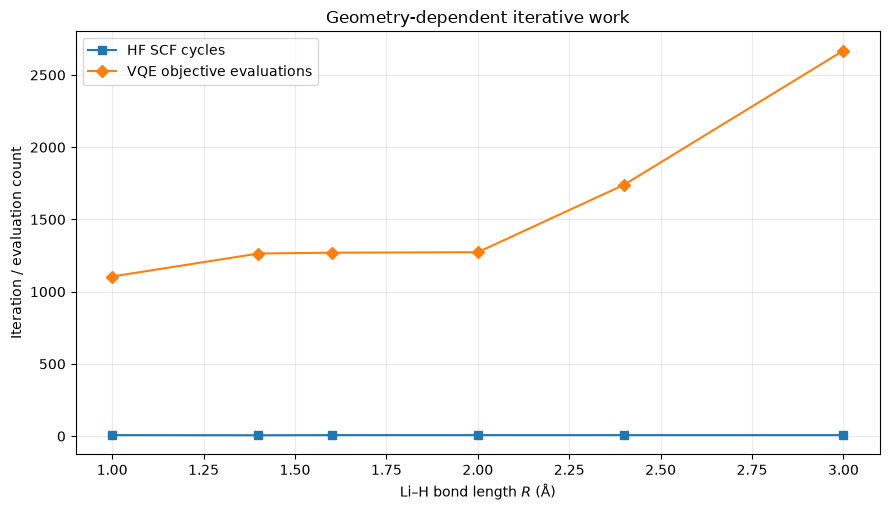

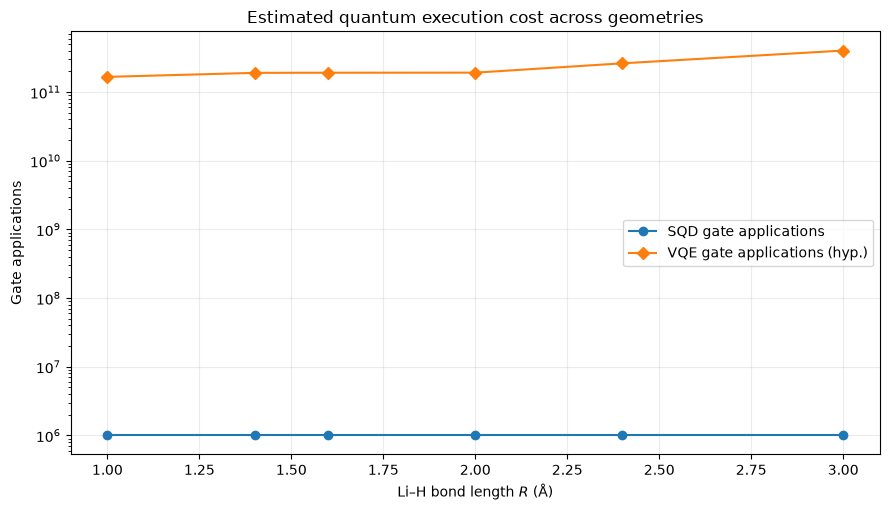

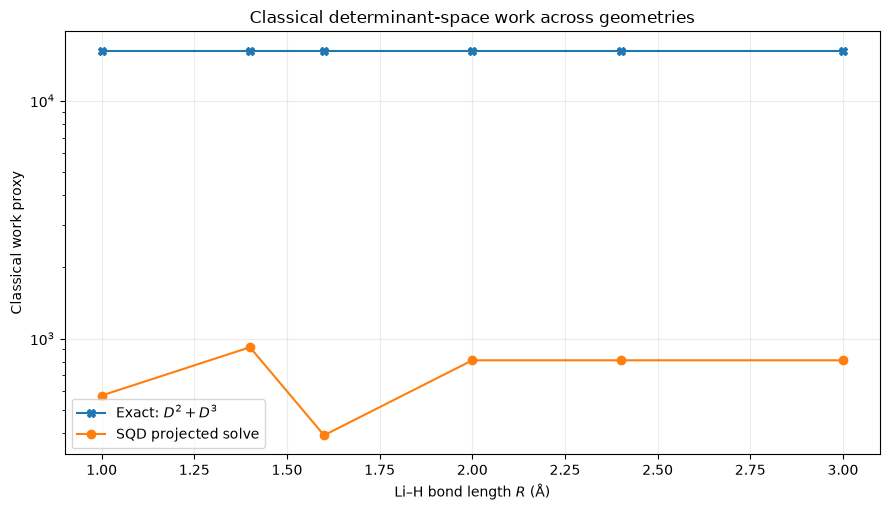

In [15]:
# ============================================================
# Step 8 — Geometry-resolved resource table
# ============================================================
def geometry_resource_row(R, sqd_shots=1000, max_strings=3):
    P = PROB[R]

    # ----- HF -----
    n_ao = int(P["mol"].nao_nr())
    hf_cycles = int(P["mf"].cycles)
    hf_work = hf_cycles * (n_ao**4 + n_ao**3)

    # ----- Exact full sector -----
    d_exact = NORB * NORB
    exact_work = d_exact**2 + d_exact**3

    # ----- SQD -----
    # Geometry-local rows from the already-run retained-subspace study.
    q = dfC[(dfC["method"] == "ccsd") &
            (dfC["R"] == R) &
            (dfC["max_strings"] == max_strings)] if "R" in dfC.columns else pd.DataFrame()

    # Step 5b may have been run only at R=2.4. If so, use Step-4 100-shot
    # geometry data for dimensions, but keep the resource assumption explicit.
    if len(q):
        sqd_dim_mean = float(q["dim"].mean())
    else:
        qa = dfA[(dfA["method"] == "ccsd") & (dfA["R"] == R)]
        sqd_dim_mean = float(qa["dim"].mean()) if len(qa) else np.nan

    sqd_circ, sqd_stats = compile_circuit(("ccsd_resource", R), ccsd_params(P))
    sqd_gates_per_shot = int(sqd_stats["total_gates"])
    sqd_2q_per_shot = int(sqd_stats["two_qubit"])
    sqd_gate_apps = sqd_shots * sqd_gates_per_shot
    sqd_2q_apps = sqd_shots * sqd_2q_per_shot
    sqd_classical_work = (sqd_dim_mean**2 + sqd_dim_mean**3
                          if np.isfinite(sqd_dim_mean) else np.nan)

    # ----- VQE -----
    v = VQE[R]
    vqe_evals = int(v["nfev"])
    vqe_groups = len(P["Hq"].group_commuting(qubit_wise=True))
    vqe_circ, vqe_stats = compile_circuit(("vqe_resource", R), v["x"])
    vqe_gates_per_measurement = int(vqe_stats["total_gates"])
    vqe_2q_per_measurement = int(vqe_stats["two_qubit"])
    vqe_hyp_shots = vqe_evals * vqe_groups * SHOTS_PER_GROUP
    vqe_gate_apps = vqe_hyp_shots * vqe_gates_per_measurement
    vqe_2q_apps = vqe_hyp_shots * vqe_2q_per_measurement

    return {
        "R": R,
        "HF cycles": hf_cycles,
        "HF classical proxy": hf_work,
        "Exact dimension": d_exact,
        "Exact classical proxy": exact_work,
        "SQD assumed shots": sqd_shots,
        "SQD gates/shot": sqd_gates_per_shot,
        "SQD 2Q/shot": sqd_2q_per_shot,
        "SQD gate apps": sqd_gate_apps,
        "SQD 2Q apps": sqd_2q_apps,
        "SQD observed dim": sqd_dim_mean,
        "SQD classical proxy": sqd_classical_work,
        "VQE evaluations": vqe_evals,
        "VQE Pauli groups": vqe_groups,
        "VQE hypothetical shots": vqe_hyp_shots,
        "VQE gates/measurement": vqe_gates_per_measurement,
        "VQE 2Q/measurement": vqe_2q_per_measurement,
        "VQE gate apps (hyp.)": vqe_gate_apps,
        "VQE 2Q apps (hyp.)": vqe_2q_apps,
        "HF error (mHa)": abs(P["e_hf"] - P["e_exact"]) * MHA,
        "VQE error (mHa)": abs(v["energy"] - P["e_exact"]) * MHA,
    }

geometry_resources = pd.DataFrame(
    [geometry_resource_row(float(R)) for R in sorted(PROB)]
)

print("Geometry-resolved resource accounting")
display(geometry_resources.round(3))

# ----- Resource quantities that genuinely change with geometry -----
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(geometry_resources["R"], geometry_resources["HF cycles"], "s-", label="HF SCF cycles")
ax.plot(geometry_resources["R"], geometry_resources["VQE evaluations"], "D-", label="VQE objective evaluations")
ax.set(xlabel="Li–H bond length $R$ (Å)", ylabel="Iteration / evaluation count",
       title="Geometry-dependent iterative work")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# Quantum execution estimate: compare SQD fixed-shot work with VQE hypothetical work.
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(geometry_resources["R"], geometry_resources["SQD gate apps"], "o-", label="SQD gate applications")
ax.plot(geometry_resources["R"], geometry_resources["VQE gate apps (hyp.)"], "D-", label="VQE gate applications (hyp.)")
ax.set_yscale("log")
ax.set(xlabel="Li–H bond length $R$ (Å)", ylabel="Gate applications",
       title="Estimated quantum execution cost across geometries")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# Classical determinant-space work.
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(geometry_resources["R"], geometry_resources["Exact classical proxy"], "X-", label="Exact: $D^2+D^3$")
ax.plot(geometry_resources["R"], geometry_resources["SQD classical proxy"], "o-", label="SQD projected solve")
ax.set_yscale("log")
ax.set(xlabel="Li–H bond length $R$ (Å)", ylabel="Classical work proxy",
       title="Classical determinant-space work across geometries")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()


### Interpretation of Step 8

These plots should **not** all be expected to change strongly with bond length.

- **Exact:** the full fixed-particle sector always contains 25 determinants, so the dense \(D^2+D^3\) proxy is constant. The Hamiltonian matrix elements change with \(R\), but the matrix dimension does not.
- **HF:** the AO basis size is constant, so the nominal per-cycle scaling is constant. Only the number of SCF iterations can change with geometry. A rise in HF cycles is therefore a convergence effect, not growth of the Hilbert space.
- **SQD quantum circuit:** the UCCSD circuit topology has the same excitation structure at every geometry. Its compiled gate count should consequently be similar. At fixed shots, quantum execution work is therefore expected to be nearly geometry-independent.
- **SQD classical solve:** this *can* change with geometry if the sampled configurations lead to different actual projected dimensions. More importantly, the **error obtained at the same dimension** can change strongly.
- **VQE:** the ansatz size is fixed, but the number of optimizer evaluations can change. Stretched geometries may present a harder variational landscape or require a different parameter solution, so the hypothetical QPU cost can vary even though the number of qubits is unchanged.

The key message is therefore:

> **Bond stretching primarily changes the physical correlation structure, not the nominal Hilbert-space size of this experiment. Resource differences across geometry arise through convergence, sampling diversity, and optimization—not through adding qubits or determinants to the full sector.**


## Step 8.5 — Geometry-dependent **accuracy versus resource** comparison

Step 8 counted work. This section asks the more important question:

> **At a given geometry, what accuracy do we obtain for the resources we spend?**

For SQD the causal chain is

\[
\boxed{
\text{shots}\rightarrow
\text{gate applications}\rightarrow
\text{sampled configurations}\rightarrow
D_{\rm SQD}\rightarrow
\Delta E
}
\]

whereas for VQE it is

\[
\boxed{
\text{objective evaluations}\rightarrow
\text{measurement groups}\rightarrow
\text{hypothetical shots}\rightarrow
\text{gate applications}\rightarrow
\Delta E
}.
\]

A crucial point is that **the same resource budget does not have to buy the same accuracy at every bond length**. At stretched LiH, the exact state can have stronger multiconfigurational character. A small sampled determinant subspace or a fixed ansatz may therefore recover a smaller fraction of the correlation energy.

To expose this, we compare all geometries in two complementary ways:

1. **Fixed-budget geometry comparison:** same SQD shot budget, compare error versus \(R\).
2. **Geometry-specific resource/accuracy points:** compare SQD and VQE gate-cost estimates against their achieved errors.

The VQE QPU cost remains hypothetical because the notebook's VQE objective uses exact statevector expectation values.

**Implementation note.** The SQD geometry statistics are aggregated directly from the raw Step-4 table `dfA` (`err_mHa`, `dim`, and `distinct_full`), so this section does not depend on the naming convention used in `sumA`.


Geometry-dependent accuracy/resource table


,R,HF error (mHa),SQD error (mHa),SQD error std (mHa),VQE error (mHa),SQD mean distinct configs,SQD mean dimension,SQD geometry-study gate apps,VQE evaluations,VQE hypothetical shots,VQE gate apps (hyp.)
0,1.0,16.659,2.706,1.319,0.0,2.8,8.0,100500,1105,64090000,166698090000
1,1.4,17.692,2.442,1.979,0.0,3.2,9.4,100500,1264,73312000,190684512000
2,1.6,20.232,2.879,2.539,0.0,3.0,7.0,100500,1270,73660000,191589660000
3,2.0,29.923,0.675,0.000,0.0,3.8,9.0,100500,1273,73834000,192042234000
4,2.4,46.961,0.406,0.000,0.0,6.6,9.0,100500,1740,100920000,262492920000
5,3.0,87.674,0.141,0.000,0.0,7.2,9.0,100500,2669,154802000,402640002000


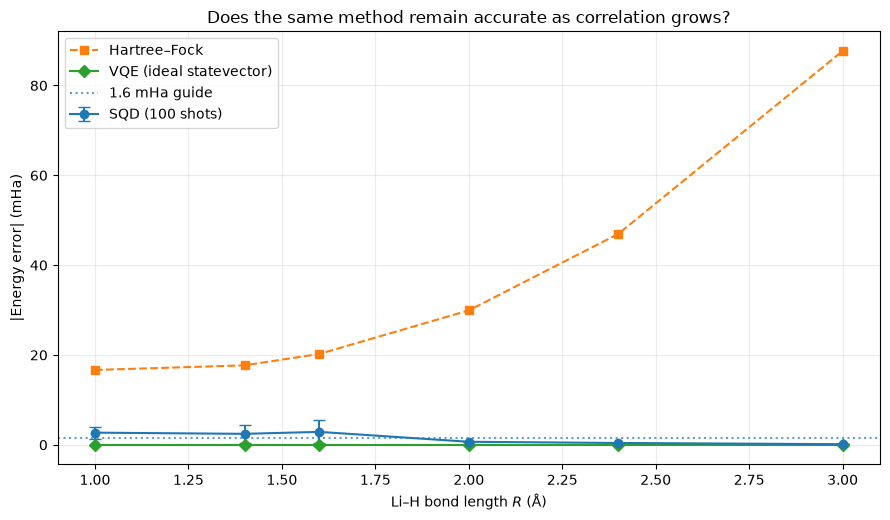

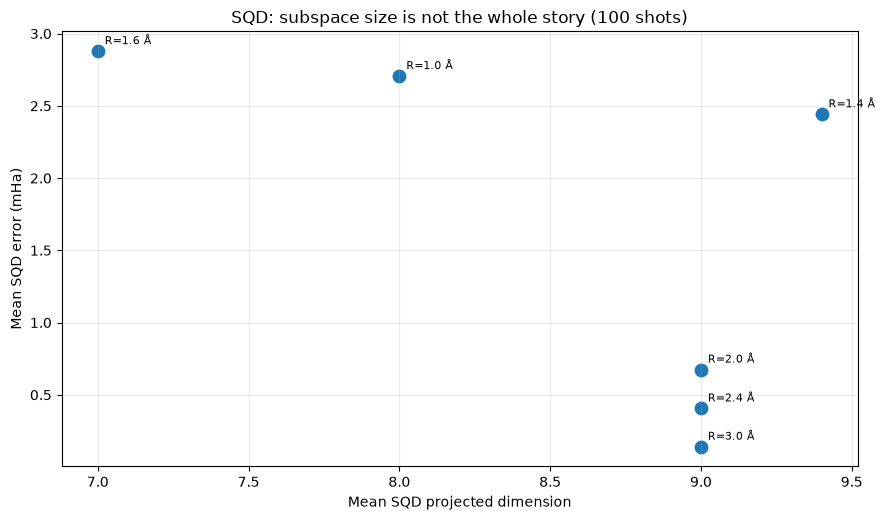

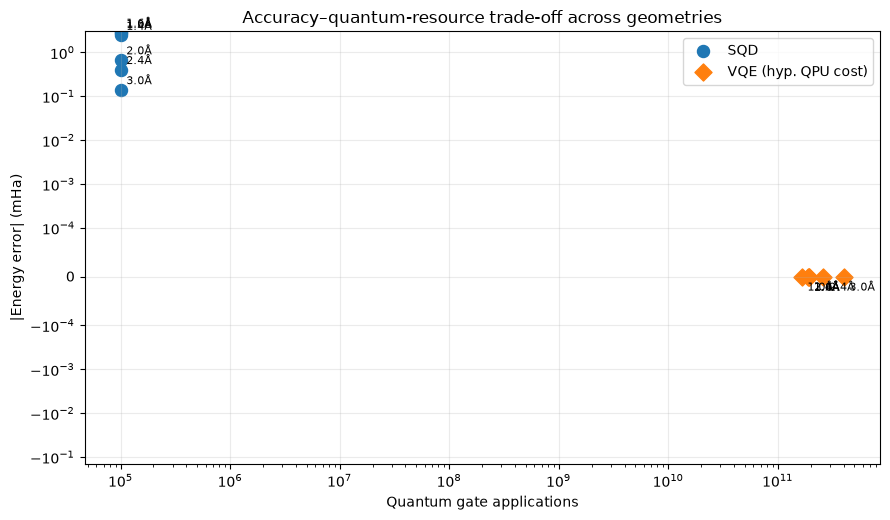

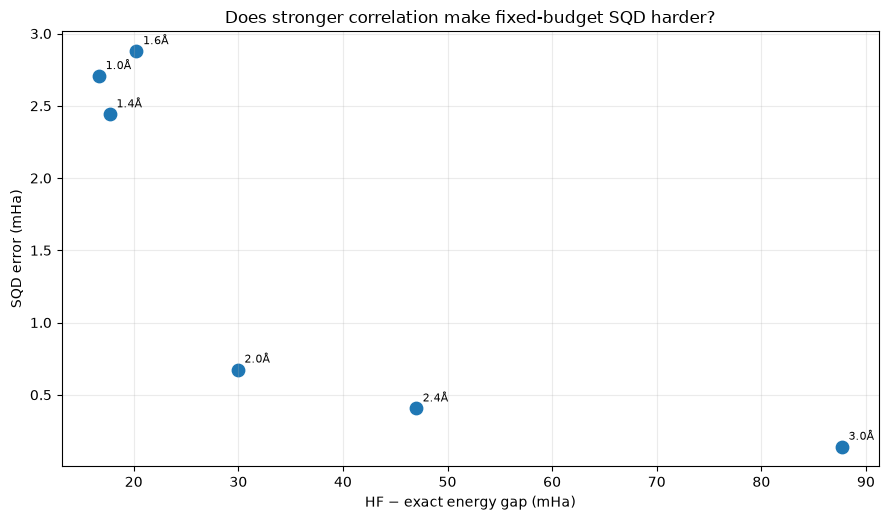

In [16]:
# ============================================================
# Step 8.5 — Geometry-dependent resource-to-accuracy analysis
# ============================================================

# Geometry-level SQD accuracy from the common Step-4 budget.
# Build these statistics directly from the raw Step-4 trial table dfA.
# This is intentionally independent of the display-oriented column names in
# sumA (where the same averaged quantities are named ``dim`` and ``distinct``).
sqd_geom = (
    dfA[dfA["method"] == "ccsd"]
    .groupby("R", as_index=False)
    .agg(
        err_mean=("err_mHa", "mean"),
        err_std=("err_mHa", "std"),
        dim_mean=("dim", "mean"),
        distinct_mean=("distinct_full", "mean"),
    )
    .sort_values("R")
)

geom_acc = geometry_resources.merge(
    sqd_geom[["R", "err_mean", "err_std", "dim_mean", "distinct_mean"]],
    on="R", how="left"
).rename(columns={
    "err_mean": "SQD error (mHa)",
    "err_std": "SQD error std (mHa)",
    "dim_mean": "SQD mean dimension",
    "distinct_mean": "SQD mean distinct configs",
})

# The Step-4 SQD curve uses its own fixed shot budget SHOTS_A.
# Recompute the matching quantum execution count for that budget.
geom_acc["SQD geometry-study gate apps"] = geom_acc["SQD gates/shot"] * SHOTS_A
geom_acc["SQD geometry-study 2Q apps"] = geom_acc["SQD 2Q/shot"] * SHOTS_A

print("Geometry-dependent accuracy/resource table")
display(geom_acc[[
    "R", "HF error (mHa)", "SQD error (mHa)", "SQD error std (mHa)",
    "VQE error (mHa)", "SQD mean distinct configs", "SQD mean dimension",
    "SQD geometry-study gate apps", "VQE evaluations",
    "VQE hypothetical shots", "VQE gate apps (hyp.)"
]].round(3))

# ---------- Figure A: fixed SQD budget, changing geometry ----------
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.errorbar(geom_acc["R"], geom_acc["SQD error (mHa)"],
            yerr=geom_acc["SQD error std (mHa)"],
            fmt="o-", capsize=4, label=f"SQD ({SHOTS_A} shots)")
ax.plot(geom_acc["R"], geom_acc["HF error (mHa)"], "s--", label="Hartree–Fock")
ax.plot(geom_acc["R"], geom_acc["VQE error (mHa)"], "D-", label="VQE (ideal statevector)")
ax.axhline(1.6, ls=":", alpha=0.7, label="1.6 mHa guide")
ax.set(xlabel="Li–H bond length $R$ (Å)", ylabel="|Energy error| (mHa)",
       title="Does the same method remain accurate as correlation grows?")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# ---------- Figure B: SQD accuracy versus actual projected dimension ----------
# Each point is a different geometry at the SAME Step-4 shot budget.
fig, ax = plt.subplots(figsize=(9, 5.3))
sc = ax.scatter(geom_acc["SQD mean dimension"], geom_acc["SQD error (mHa)"], s=80)
for _, row in geom_acc.iterrows():
    ax.annotate(f'R={row["R"]:.1f} Å',
                (row["SQD mean dimension"], row["SQD error (mHa)"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(xlabel="Mean SQD projected dimension",
       ylabel="Mean SQD error (mHa)",
       title=f"SQD: subspace size is not the whole story ({SHOTS_A} shots)")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

# ---------- Figure C: quantum resource vs accuracy, colored conceptually by geometry ----------
# SQD points: common finite-shot geometry study.
# VQE points: ideal achieved error paired with hypothetical finite-shot QPU cost.
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.scatter(geom_acc["SQD geometry-study gate apps"], geom_acc["SQD error (mHa)"],
           s=75, marker="o", label="SQD")
ax.scatter(geom_acc["VQE gate apps (hyp.)"], geom_acc["VQE error (mHa)"],
           s=75, marker="D", label="VQE (hyp. QPU cost)")
for _, row in geom_acc.iterrows():
    ax.annotate(f'{row["R"]:.1f}Å',
                (row["SQD geometry-study gate apps"], row["SQD error (mHa)"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.annotate(f'{row["R"]:.1f}Å',
                (row["VQE gate apps (hyp.)"], row["VQE error (mHa)"]),
                xytext=(4, -10), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
# symlog safely accommodates exact/near-zero VQE errors.
ax.set_yscale("symlog", linthresh=1e-4)
ax.set(xlabel="Quantum gate applications",
       ylabel="|Energy error| (mHa)",
       title="Accuracy–quantum-resource trade-off across geometries")
ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()

# ---------- Figure D: correlation difficulty versus SQD error ----------
# HF-exact separation is used as a simple measure of how much correlation
# the single-determinant HF reference misses.
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.scatter(geom_acc["HF error (mHa)"], geom_acc["SQD error (mHa)"], s=80)
for _, row in geom_acc.iterrows():
    ax.annotate(f'{row["R"]:.1f}Å',
                (row["HF error (mHa)"], row["SQD error (mHa)"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(xlabel="HF − exact energy gap (mHa)",
       ylabel="SQD error (mHa)",
       title="Does stronger correlation make fixed-budget SQD harder?")
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


### What changes meaningfully with geometry?

The answer is **yes for accuracy, but only partly for nominal operation counts**.

#### 1. Energy curves change meaningfully

The HF–exact separation grows as LiH is stretched. In this notebook that separation is a convenient measure of the correlation energy missed by the single-determinant HF description. Therefore the stretched geometries are a more demanding test of whether SQD or VQE can represent correlated electronic structure.

The total-energy plot can visually hide this because all methods share a large common energy. The error and correlation-recovery plots are more diagnostic.

#### 2. Exact-operation proxy should barely change

Every geometry uses the same 5 active spatial orbitals, 2 active electrons and 25-determinant \((1,1)\) sector. Thus the dense exact-diagonalization dimension is unchanged:

\[
D_{\rm exact}=25.
\]

The Hamiltonian *numbers* change with \(R\), but the formal dense matrix size does not.

#### 3. HF cost may change modestly

The basis size is unchanged, so the nominal cost per SCF cycle is unchanged. Geometry can nevertheless change the number of iterations required for self-consistency. Any variation in the HF work plot should be interpreted as **convergence difficulty**, not a larger electronic Hilbert space.

#### 4. SQD is where geometry is especially informative

At a fixed number of shots, the compiled circuit cost is expected to remain similar because the UCCSD excitation structure is unchanged. But the **set of determinants sampled and their probabilities can change strongly with \(R\)**.

This means two geometries can have similar:

- qubit count,
- circuit depth,
- shots,
- even projected dimension,

yet noticeably different SQD errors.

That is physically important. It shows that

\[
\boxed{\text{subspace dimension alone does not determine subspace quality}.}
\]

A 9-dimensional subspace containing the important determinants can be much better than a different 9-dimensional subspace.

#### 5. VQE geometry dependence enters mainly through optimization

The UCCSD parameter count is fixed, but the optimized amplitudes and the number of objective evaluations can vary with geometry. Thus a stretched bond may increase the optimization burden without changing the qubit count.

Because this notebook uses ideal statevector VQE, its energy error and its plotted hypothetical QPU measurement cost answer two different questions:

- **energy:** how expressive/optimizable is the UCCSD ansatz?
- **hypothetical gate cost:** what would repeated finite-shot energy estimation approximately cost?

Do not claim that the latter was actually executed.

### Presentation conclusion

The geometry study supports a stronger statement than “the algorithms use different numbers of operations”:

> **The nominal problem size is fixed across the LiH scan, but the electronic correlation structure changes. Consequently, exact dense-solve size and circuit architecture remain nearly fixed, while the accuracy obtained from a fixed SQD sampling budget and the optimization effort required by VQE can change with bond length.**

That is the physically meaningful comparison. It separates **computational size** from **electronic-structure difficulty**, which is exactly why the stretched-bond points are valuable in this benchmark.


## Step 8.75 — Why does SQD work? Exact determinant-weight captured by the sampled subspace

Energy error tells us **whether** SQD works, but not **why**. Because LiH has only 25 determinants in the fixed $(N_\\alpha,N_\\beta)=(1,1)$ sector, we can diagonalize the full sector and inspect the exact ground-state expansion

$$|\\Psi_0\\rangle=\\sum_D c_D|D\\rangle.$$

For an SQD-selected determinant subspace $S$, define the **captured exact weight**

$$W_S=\\sum_{D\\in S}|c_D|^2.$$

$W_S=1$ means the selected determinant basis contains all probability weight of the exact state; a small $W_S$ means important exact configurations were missed. This is a diagnostic only: **the exact state is never used to generate the SQD samples.**

We compare three selectors at the same number $D$ of full determinants:

- **SQD sampled:** determinants observed from the finite-shot CCSD-seeded quantum circuit.
- **Random:** a uniformly chosen $D$-determinant subset, averaged over many random subsets.
- **Oracle:** the $D$ determinants with largest exact $|c_D|^2$. This is an unattainable post-hoc upper benchmark, not an algorithm.

Two plots are especially informative: captured exact weight $W_S(D)$ and projected-ground-state energy error $\\Delta E(D)$. If SQD lies much closer to the oracle than to random selection, the circuit is doing useful **configuration selection**, rather than merely producing an arbitrary small subspace.

### What changes for a larger molecule?

For $M$ active spatial orbitals with fixed $(N_\\alpha,N_\\beta)$, the determinant-sector size is

$$D_{\\rm full}=\\binom{M}{N_\\alpha}\\binom{M}{N_\\beta}.$$

This grows combinatorially. The central promise of SQD is therefore not that diagonalization disappears, but that a physically useful sampled subspace $D_{\\rm SQD}\\ll D_{\\rm full}$ might capture most of the important wavefunction support. On LiH we can verify this directly with $W_S$ because exact FCI is cheap. For genuinely large active spaces, computing the exact $c_D$ defeats the purpose; $W_S$ becomes a **validation metric for tractable benchmark systems**, while practical large-system assessment must rely on convergence with sampling/subspace size, independent high-quality references where available, and observables.


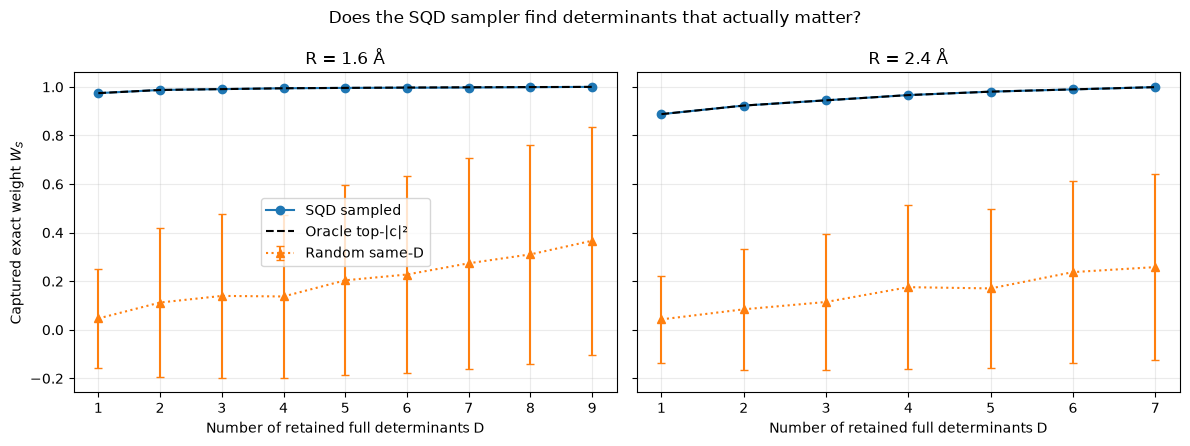

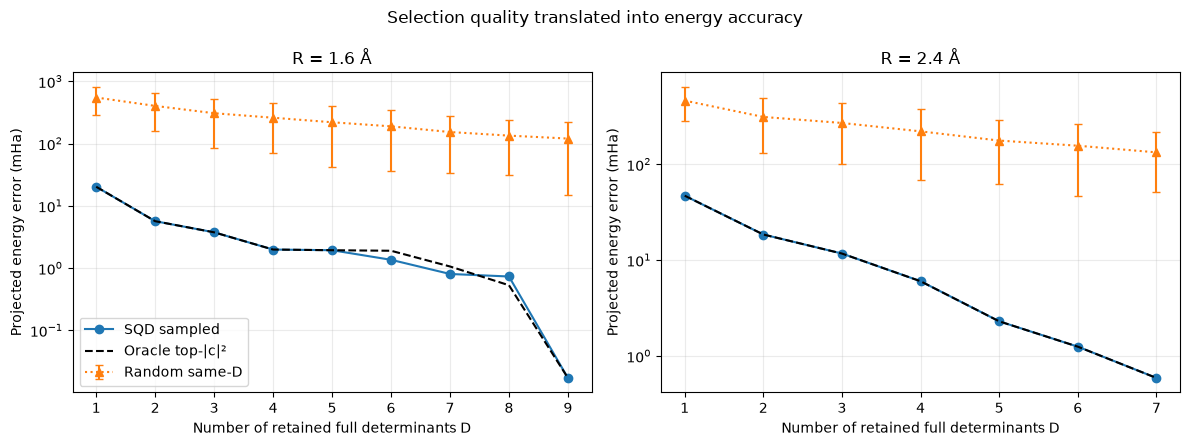

,R,D,SQD_weight,Random_weight,Oracle_weight,SQD_error_mHa,Random_error_mHa,Oracle_error_mHa
0,1.0,5,0.99498,0.25340,0.99639,3.27783,208.91211,1.33231
1,1.4,5,0.99465,0.20964,0.99632,2.64815,228.56693,1.89349
2,1.6,5,0.99582,0.22414,0.99582,1.93531,210.03723,1.93531
3,2.0,5,0.99176,0.19519,0.99211,2.76319,200.34538,1.43950
4,2.4,5,0.98036,0.21640,0.98036,2.29321,173.13857,2.29321
5,3.0,5,0.94837,0.21907,0.94837,5.45016,171.27090,5.45016


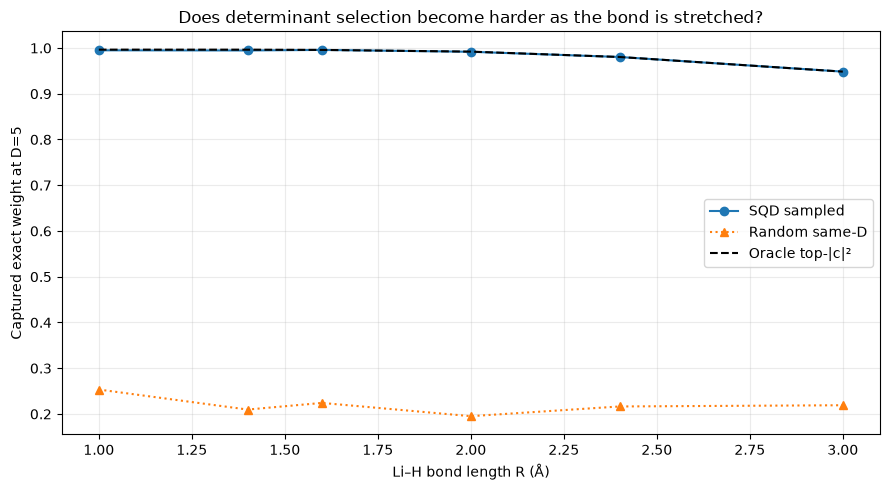

,M,Nalpha,Nbeta,spin_orbitals,D_full
0,2,1,1,4,4
1,3,1,1,6,9
2,4,2,2,8,36
3,5,2,2,10,100
4,6,3,3,12,400
5,7,3,3,14,1225
6,8,4,4,16,4900
7,9,4,4,18,15876
8,10,5,5,20,63504
9,11,5,5,22,213444


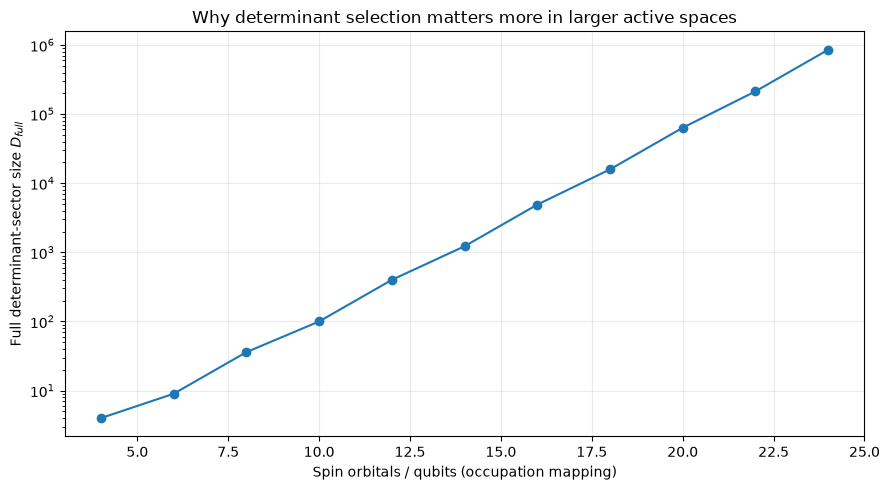

Interpretation:
  • W_S measures whether SQD selected determinants carrying exact ground-state probability.
  • The oracle is post-hoc only; it is not used by SQD.
  • Random same-D controls for classical subspace dimension.
  • For larger active spaces D_full grows combinatorially, so exact W_S eventually becomes unavailable;
    the LiH calculation is therefore a validation experiment for the configuration-selection mechanism.


In [17]:
# ============================================================
# Step 8.75 — Determinant-selection quality: why SQD works
# ============================================================
from math import comb

# Full determinant basis in the same qubit ordering used throughout the notebook.
FULL_DETS = [(a, b) for a in alpha_strs for b in alpha_strs]
FULL_IDX = np.array([(b << NORB) | a for a, b in FULL_DETS], dtype=int)


def exact_sector_data(p):
    """Exact ground state in the 25-dimensional (1 alpha, 1 beta) determinant sector."""
    Hsec = p["M"][FULL_IDX][:, FULL_IDX].toarray()
    vals, vecs = np.linalg.eigh(Hsec)
    psi0 = vecs[:, 0]
    weights = np.abs(psi0)**2
    return vals[0] + p["ecore"], psi0, weights, Hsec


def projected_energy_from_positions(Hsec, positions, ecore):
    """Lowest energy in an arbitrary subset of full determinants."""
    positions = np.array(sorted(set(positions)), dtype=int)
    Hsub = Hsec[np.ix_(positions, positions)]
    return np.linalg.eigvalsh(Hsub)[0] + ecore


def observed_full_determinants(counts):
    """Rank valid measured full determinants by observed frequency."""
    ranked = []
    for s, c in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
        s = s.replace(" ", "")
        b_bits, a_bits = s[:NORB], s[NORB:]
        if a_bits.count("1") == NA and b_bits.count("1") == NB:
            ranked.append(((int(a_bits, 2), int(b_bits, 2)), c))
    return ranked


def selection_diagnostic(R, shots=1000, seed=0, random_repeats=300):
    p = PROB[R]
    e0, psi0, weights, Hsec = exact_sector_data(p)
    pos = {det: i for i, det in enumerate(FULL_DETS)}

    counts = sample_counts(("weight_diag", R), ccsd_params(p), shots, seed)
    ranked_obs = observed_full_determinants(counts)
    sqd_positions = [pos[d] for d, _ in ranked_obs]

    # Oracle ranks determinants by exact probability weight. Used only after sampling.
    oracle_positions = list(np.argsort(weights)[::-1])
    rng = np.random.default_rng(50_000 + seed + int(round(100 * R)))

    rows = []
    max_D = len(sqd_positions)
    for D in range(1, max_D + 1):
        sq = sqd_positions[:D]
        oracle = oracle_positions[:D]

        sq_w = float(weights[sq].sum())
        oracle_w = float(weights[oracle].sum())
        sq_e = projected_energy_from_positions(Hsec, sq, p["ecore"])
        oracle_e = projected_energy_from_positions(Hsec, oracle, p["ecore"])

        random_w, random_err = [], []
        for _ in range(random_repeats):
            rr = rng.choice(len(FULL_DETS), size=D, replace=False)
            random_w.append(float(weights[rr].sum()))
            random_err.append((projected_energy_from_positions(Hsec, rr, p["ecore"]) - e0) * MHA)

        rows.append(dict(
            R=R, D=D,
            sqd_weight=sq_w, oracle_weight=oracle_w,
            random_weight_mean=np.mean(random_w), random_weight_std=np.std(random_w),
            sqd_error_mHa=(sq_e-e0)*MHA,
            oracle_error_mHa=(oracle_e-e0)*MHA,
            random_error_mean_mHa=np.mean(random_err), random_error_std_mHa=np.std(random_err),
        ))
    return pd.DataFrame(rows), weights, ranked_obs

# Use a near-equilibrium and a stretched geometry to expose the correlation effect.
DIAG_GEOMS = [1.6, 2.4]
WEIGHT_DIAG = {}
for R in DIAG_GEOMS:
    d, weights, ranked = selection_diagnostic(R, shots=1000, seed=0)
    WEIGHT_DIAG[R] = dict(table=d, weights=weights, ranked=ranked)

# ----- Plot 1: how much exact wavefunction weight is captured? -----
fig, axes = plt.subplots(1, len(DIAG_GEOMS), figsize=(12, 4.5), sharey=True)
for ax, R in zip(np.atleast_1d(axes), DIAG_GEOMS):
    d = WEIGHT_DIAG[R]["table"]
    ax.plot(d.D, d.sqd_weight, "o-", label="SQD sampled")
    ax.plot(d.D, d.oracle_weight, "k--", label="Oracle top-|c|²")
    ax.errorbar(d.D, d.random_weight_mean, yerr=d.random_weight_std,
                fmt="^:", capsize=3, label="Random same-D")
    ax.set(title=f"R = {R:.1f} Å", xlabel="Number of retained full determinants D")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"Captured exact weight $W_S$")
axes[0].legend()
fig.suptitle("Does the SQD sampler find determinants that actually matter?")
plt.tight_layout(); plt.show()

# ----- Plot 2: energy consequence of those selections -----
fig, axes = plt.subplots(1, len(DIAG_GEOMS), figsize=(12, 4.5), sharey=False)
for ax, R in zip(np.atleast_1d(axes), DIAG_GEOMS):
    d = WEIGHT_DIAG[R]["table"]
    ax.plot(d.D, d.sqd_error_mHa, "o-", label="SQD sampled")
    ax.plot(d.D, d.oracle_error_mHa, "k--", label="Oracle top-|c|²")
    ax.errorbar(d.D, d.random_error_mean_mHa, yerr=d.random_error_std_mHa,
                fmt="^:", capsize=3, label="Random same-D")
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.set(title=f"R = {R:.1f} Å", xlabel="Number of retained full determinants D",
           ylabel="Projected energy error (mHa)")
    ax.grid(alpha=0.25)
axes[0].legend()
fig.suptitle("Selection quality translated into energy accuracy")
plt.tight_layout(); plt.show()

# ----- Geometry summary at a common determinant budget -----
COMMON_D = 5
rows = []
for R in sorted(PROB):
    d, weights, ranked = selection_diagnostic(R, shots=1000, seed=0, random_repeats=200)
    use = d[d.D == min(COMMON_D, d.D.max())].iloc[0]
    rows.append(dict(R=R, D=int(use.D), SQD_weight=use.sqd_weight,
                     Random_weight=use.random_weight_mean, Oracle_weight=use.oracle_weight,
                     SQD_error_mHa=use.sqd_error_mHa,
                     Random_error_mHa=use.random_error_mean_mHa,
                     Oracle_error_mHa=use.oracle_error_mHa))
weight_by_geometry = pd.DataFrame(rows)
display(weight_by_geometry.round(5))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(weight_by_geometry.R, weight_by_geometry.SQD_weight, "o-", label="SQD sampled")
ax.plot(weight_by_geometry.R, weight_by_geometry.Random_weight, "^:", label="Random same-D")
ax.plot(weight_by_geometry.R, weight_by_geometry.Oracle_weight, "k--", label="Oracle top-|c|²")
ax.set(xlabel="Li–H bond length R (Å)", ylabel=fr"Captured exact weight at D={COMMON_D}",
       title="Does determinant selection become harder as the bond is stretched?")
ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()

# ----- Larger-active-space assessment: combinatorial determinant growth -----
# Illustrative closed-shell half-filling sequence. This is a scaling diagnostic,
# not a simulation of a specific larger molecule.
scaling_rows = []
for M in range(2, 13):
    nalpha = nbeta = M // 2
    Dfull = comb(M, nalpha) * comb(M, nbeta)
    scaling_rows.append(dict(M=M, Nalpha=nalpha, Nbeta=nbeta,
                             spin_orbitals=2*M, D_full=Dfull))
space_scaling = pd.DataFrame(scaling_rows)
display(space_scaling)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(space_scaling.spin_orbitals, space_scaling.D_full, "o-")
ax.set_yscale("log")
ax.set(xlabel="Spin orbitals / qubits (occupation mapping)",
       ylabel=r"Full determinant-sector size $D_{full}$",
       title="Why determinant selection matters more in larger active spaces")
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

print("Interpretation:")
print("  • W_S measures whether SQD selected determinants carrying exact ground-state probability.")
print("  • The oracle is post-hoc only; it is not used by SQD.")
print("  • Random same-D controls for classical subspace dimension.")
print("  • For larger active spaces D_full grows combinatorially, so exact W_S eventually becomes unavailable;")
print("    the LiH calculation is therefore a validation experiment for the configuration-selection mechanism.")


## Step 9 — Total cost ledger

Everything that was run is in `LEDGER`: classical CCSD preprocessing, transpilation, every sampling batch (and its seed), every projected solve, and the VQE optimisation. Circuit metrics are for the **compiled `{cx, rz, sx, x}` circuits**.

**Note:** Step 8.5 is derived entirely from results already generated in this notebook; it does not add another quantum batch or VQE optimisation. The Pareto/resource figures therefore reuse the recorded experimental budgets and clearly label hypothetical VQE measurement costs.


In [18]:
L = pd.DataFrame(LEDGER)
summary = L.groupby("stage").agg(calls=("stage", "size"), seconds=("seconds", "sum"),
                                 shots=("shots", "sum"), evals=("evals", "sum")).fillna(0)
display(summary.round(3))
tr = L[L.stage == "transpile"][["key", "qubits", "depth", "two_qubit", "total_gates"]].drop_duplicates("key")
print("Compiled-circuit metrics (examples):"); display(tr.head(8))
print("Total circuit shots (SQD sampling, simulator):", int(L.shots.fillna(0).sum()))
print("Total hypothetical shots if VQE were run on a QPU:", int(L.hypothetical_shots.fillna(0).sum()))

,calls,seconds,shots,evals
stage,,,,
classical_CCSD,6,0.145,0.0,0.0
sample_circuit,125,1.343,47475.0,0.0
sqd_solve,211,0.369,0.0,0.0
transpile,26,0.248,0.0,0.0
vqe_optimise,6,62.201,0.0,9321.0


Compiled-circuit metrics (examples):


,key,qubits,depth,two_qubit,total_gates
6,"('ccsd', 1.6)",10.0,730.0,576.0,1005.0
8,"('ccsd', 2.4)",10.0,730.0,576.0,1005.0
11,"('ccsd', 1.0)",10.0,730.0,576.0,1005.0
27,"('ccsd', 1.4)",10.0,730.0,576.0,1005.0
58,"('ccsd', 2.0)",10.0,730.0,576.0,1005.0
89,"('ccsd', 3.0)",10.0,730.0,576.0,1005.0
296,"('vqe', 2.4)",10.0,1940.0,1520.0,2601.0
317,"('rand', 2.4)",10.0,1940.0,1520.0,2601.0


Total circuit shots (SQD sampling, simulator): 47475
Total hypothetical shots if VQE were run on a QPU: 540618000


## Results summary (seeds 0–4 as in this notebook; numbers are from our reference run)

**Reference values.** HF error grows from 16.7 mHa (1.0 Å) to 46.96 mHa (2.4 Å) and 87.7 mHa (3.0 Å): the stretched bond is strongly correlated, so a single determinant fails.

**1. Same shots → uniform baseline wins (saturation).** The valid sector has only 25 determinants (5 spin-strings). A uniform sampler covers all of them after ~10 shots and returns the exact energy (0.000 mHa). The CCSD-seeded circuit puts ~88 % of its weight on the HF determinant (P(HF)=0.88 at 2.4 Å), so it keeps re-sampling the same strings: 6.6 distinct configurations / dim 9 at 100 shots, with error 0.41 mHa at 2.4 Å. At 1.0–1.6 Å the state is even closer to HF and 100 shots often give only ~3 strings, leaving 2–3 mHa errors. This is a **valid negative result for "quantum samples beat random"** on a toy-size sector — it says nothing about quantum advantage.

**2. Same *solve dimension* → CCSD-seeded samples are far more useful.** When the subspace is capped (Step 5b), keeping the 3 most frequent strings (dim 9) gives 0.41 mHa with CCSD-seeded samples vs ≈ 269 mHa for uniform samples (whose "most frequent" strings are arbitrary and usually miss HF). At dim 4: 18.4 mHa vs ≈ 404 mHa. So the circuit is a good **selector** of important configurations; it is a poor **explorer** of the whole space. If the classical solve were the bottleneck (much larger sector), this would be the regime that matters; here the 25×25 solve costs milliseconds, so there is no cost pressure to truncate.

**3. Variability.** Independent runs are not nested, so error is not monotone in shots (e.g. CCSD-seeded: 9.3 ± 20 mHa at 30 shots, 0.41 ± 0 at 100). Errors at low shots are bimodal: either HF-only (46.96 mHa) or a useful subspace.

**4. VQE.** Ideal (shot-free) UCCSD-VQE reaches the exact sector energy to < 10⁻⁵ Ha at every geometry but needs 1.2k–3k energy evaluations per geometry (≈ 10⁸ hypothetical shots with 58 measurement groups × 1000 shots each) and a 1.5–2× deeper compiled circuit; the CCSD-seeded circuit's own <H> is 14 mHa off at 2.4 Å and 53 mHa off at 3.0 Å, yet SQD on its samples is within 0.4 mHa at 2.4 Å, because SQD only needs the right *configurations*, not the right *amplitudes*.

**5. Design test (Step 7).** Same circuit structure, different parameters: CCSD-seeded and VQE-trained circuits give identical SQD accuracy at 30/100 shots (0.41 mHa) — the expensive optimisation buys nothing for configuration selection here. A random-angle circuit scrambles the state (P(HF)≈0) and gives 300–380 mHa errors at the same shots; random angles ≠ uniform sampling, and it is worse than both.

**Conclusion for this experiment.** Best accuracy/cost trade-off: *CCSD-seeded circuit + SQD with a capped subspace* (≈ 0.4 mHa at dim 9, ~100 shots, ~0.3 s total classical CCSD) — it matches VQE-quality energies at a tiny fraction of the optimisation cost. If you can afford the full 25-dimension solve, uniform sampling is as good or better, so no sampling advantage is claimed.

### Caveats worth stating in your README
* Ideal noiseless simulator; no configuration recovery. Compiled depth/2-qubit counts depend on which angles are exactly zero (the transpiler drops symmetry-forbidden near-zero rotations), so the CCSD circuit (depth 730, 576 CX) looks cheaper than VQE/random circuits (depth 1940, 1520 CX); the *logical* ansatz is identical.
* Tiny 25-determinant sector ⇒ saturation; use a larger active space for genuine truncation studies.
* VQE uses exact expectation values; hypothetical shots are an estimate, not a measurement.
* 5 seeds → rough spread only; raise `SEEDS` for the final report.

### Next steps for the challenge repository
Public GitHub repo with this notebook, a `README.md` (problem, setup, run steps, results, limitations), pinned versions (`pip freeze`), saved figures. Then add one extension: a bit-flip/noise model with discard vs `recover_configurations`, or a larger active space (e.g. LiH without freezing the core, or H₂O / N₂).